In [5]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('val_rmse','mean'),
                avg_mae=('val_mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse')
    topk_df = agg.groupby(['method'], group_keys=False).head(k)
    topk_d = topk_df[['method', 'avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df




In [7]:
data = pd.read_csv('results/300_gaussian_6.csv')

Text(0, 0.5, 'RMSE')

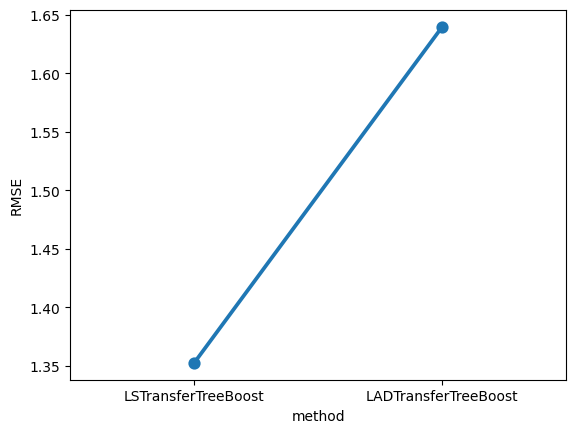

In [8]:
LS_data = data[data['method'] == 'LSTransferTreeBoost']
LAD_data = data[data['method'] == 'LADTransferTreeBoost']

best_LS, _ = topk_per_d_per_method(
    LS_data,
['v', 'target_tree_size'], k=1
)

best_LAD, _ = topk_per_d_per_method(
    LAD_data,
['v', 'target_tree_size'], k=1
)


df = pd.concat([best_LS, best_LAD])
sns.pointplot(data = df, x = 'method', y = 'rmse')
plt.ylabel('RMSE')




In [9]:
sns.lineplot(data = best_params_for_us, x = 'd', y = 'source_tree_size', errorbar=None)

NameError: name 'best_params_for_us' is not defined